# **Thyroid Cancer** | 15042025
---

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

Untuk semua pejuang kanker di luar sana — semoga setiap hari membawa kekuatan baru, setiap langkah mendekatkan pada kesembuhan, dan setiap napas diselimuti harapan.

---

Kanker merupakan penyakit yang sangat fatal dan bisa menyerang siapapun, sampai saat ini tidak ada obat absolut yang dapat menyembuhkan kanker. Jika katanya ada pun, obat tersebut hanya mampu untuk menekan dampak dan pertumbuhan kanker, tidak secara keseluruhan.

Kali ini, kami mendapatkan sebuah dataset dari pihak rumah sakit, dr. Guntur, untuk membuat model yang mampu memprediksi apakah seorang pasien yang pernah mengidap kanker dapat kambuh lagi atau tidak, dengan tujuan agar dokter bisa memberikan treatment yang tepat pada pasien tersebut sebelum berdampak lebih fatal, dengan berdasarkan data observasi yang telah dikumpulkan sebelumnya.

## ***B. Import Libraries***

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## ***C. Import Dataset***

In [2]:
dataset = pd.read_csv("filtered_thyroid_data.csv")
dataset

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,No,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Dafatr Variabel

In [3]:
dataset.columns

Index(['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

1. `Age`: usia pasien (numerik) 

2. `Gender`: jenis kelamin (M, F) 
3. `Hx Radiothreapy`: riwayat radioterapi (Yes, No) 
4. `Adenopathy`: pembesaran kelenjar getah bening (Yes, No) 
5. `Pathology`: tipe kanker (contoh: Micropapillary) 
6. `Focality`: jumlah fokus tumor (Uni-Focal, Multi-Focal) 
7. `Risk`: klasifikasi risiko kanker (Low, Intermediate, High) 
8. `T`: klasifikasi tumor (T1a, T2, dsb) 
9. `N`: klasifikasi nodus limfa (N0, N1) 
10. `M`: metastasis (M0, M1) 
11. `Stage`: stadium kanker (I, II, III, IV) 
12. `Response`: hasil respon pengobatan (Excellent, Indeterminate, dll) 
13. `Recurred`: kekambuhan (Yes, No)

### 2. Inspeksi Informasi Ringkas

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              383 non-null    int64 
 1   Gender           383 non-null    object
 2   Hx Radiothreapy  383 non-null    object
 3   Adenopathy       383 non-null    object
 4   Pathology        383 non-null    object
 5   Focality         383 non-null    object
 6   Risk             383 non-null    object
 7   T                383 non-null    object
 8   N                383 non-null    object
 9   M                383 non-null    object
 10  Stage            383 non-null    object
 11  Response         383 non-null    object
 12  Recurred         383 non-null    object
dtypes: int64(1), object(12)
memory usage: 39.0+ KB


Semua kolom merupakan kategorikal kecuali `Age`, yang merupakan numerik kontinu.

In [5]:
all_feature_cols = ['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']
continu_cols = ['Age']
categorical_cols = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']
target_col = ['Recurred']

### 3. Inspeksi Statistik Deskriptif

In [6]:
dataset.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


### 4. Inspeksi Data NaN

In [7]:
dataset.isna().sum()

Age                0
Gender             0
Hx Radiothreapy    0
Adenopathy         0
Pathology          0
Focality           0
Risk               0
T                  0
N                  0
M                  0
Stage              0
Response           0
Recurred           0
dtype: int64

### 5. Inspeksi Data Duplicated

In [8]:
dataset.duplicated().sum()

np.int64(53)

### 6. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

In [9]:
target_counts = dataset["Recurred"].value_counts()
target_counts

Recurred
No     275
Yes    108
Name: count, dtype: int64

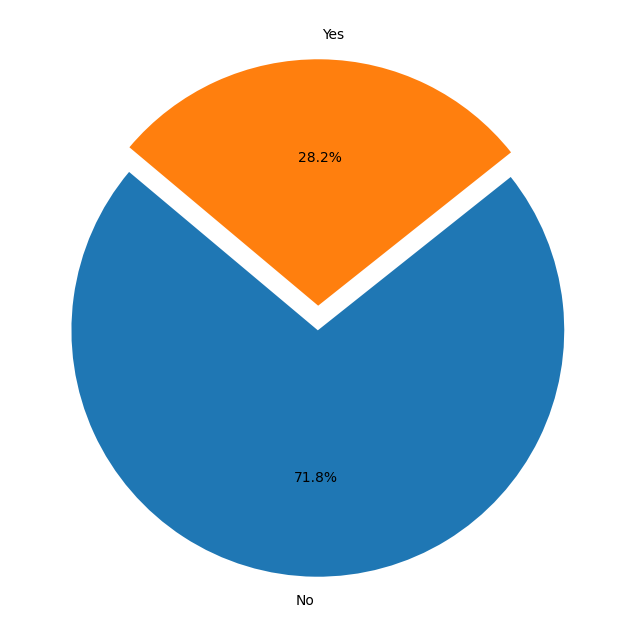

In [10]:
explodes = [0.05] * len(target_counts)
color = plt.get_cmap('tab10').colors

plt.figure(figsize=(8, 8))
plt.pie(
    target_counts,
    labels =target_counts.index,
    explode=explodes,
    colors=color,
    autopct="%1.1f%%",
    startangle=140
)
plt.show()

#### *b. Inspeksi Distribusi Setiap Fitur*

In [11]:
def check_value(dataset, feature):
    for col in dataset[feature]:
        print(dataset[col].value_counts(dropna=False))
        print()

check_value(dataset, categorical_cols)

Gender
F    312
M     71
Name: count, dtype: int64

Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64

Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, dtype: int64

Pathology
Papillary         287
Micropapillary     48
Follicular         28
Hurthel cell       20
Name: count, dtype: int64

Focality
Uni-Focal      247
Multi-Focal    136
Name: count, dtype: int64

Risk
Low             249
Intermediate    102
High             32
Name: count, dtype: int64

T
T2     151
T3a     96
T1a     49
T1b     43
T4a     20
T3b     16
T4b      8
Name: count, dtype: int64

N
N0     268
N1b     93
N1a     22
Name: count, dtype: int64

M
M0    365
M1     18
Name: count, dtype: int64

Stage
I      333
II      32
IVB     11
III      4
IVA      3
Name: count, dtype: int64

Response
Excellent                 208
Structural Incomplete      91
Indeterminate              61
Biochemical Incomplete     23
Name: count, dtype

### 7. Bivariate Analysis

#### *a. Inspeksi Distribusi Fitur dengan Target*

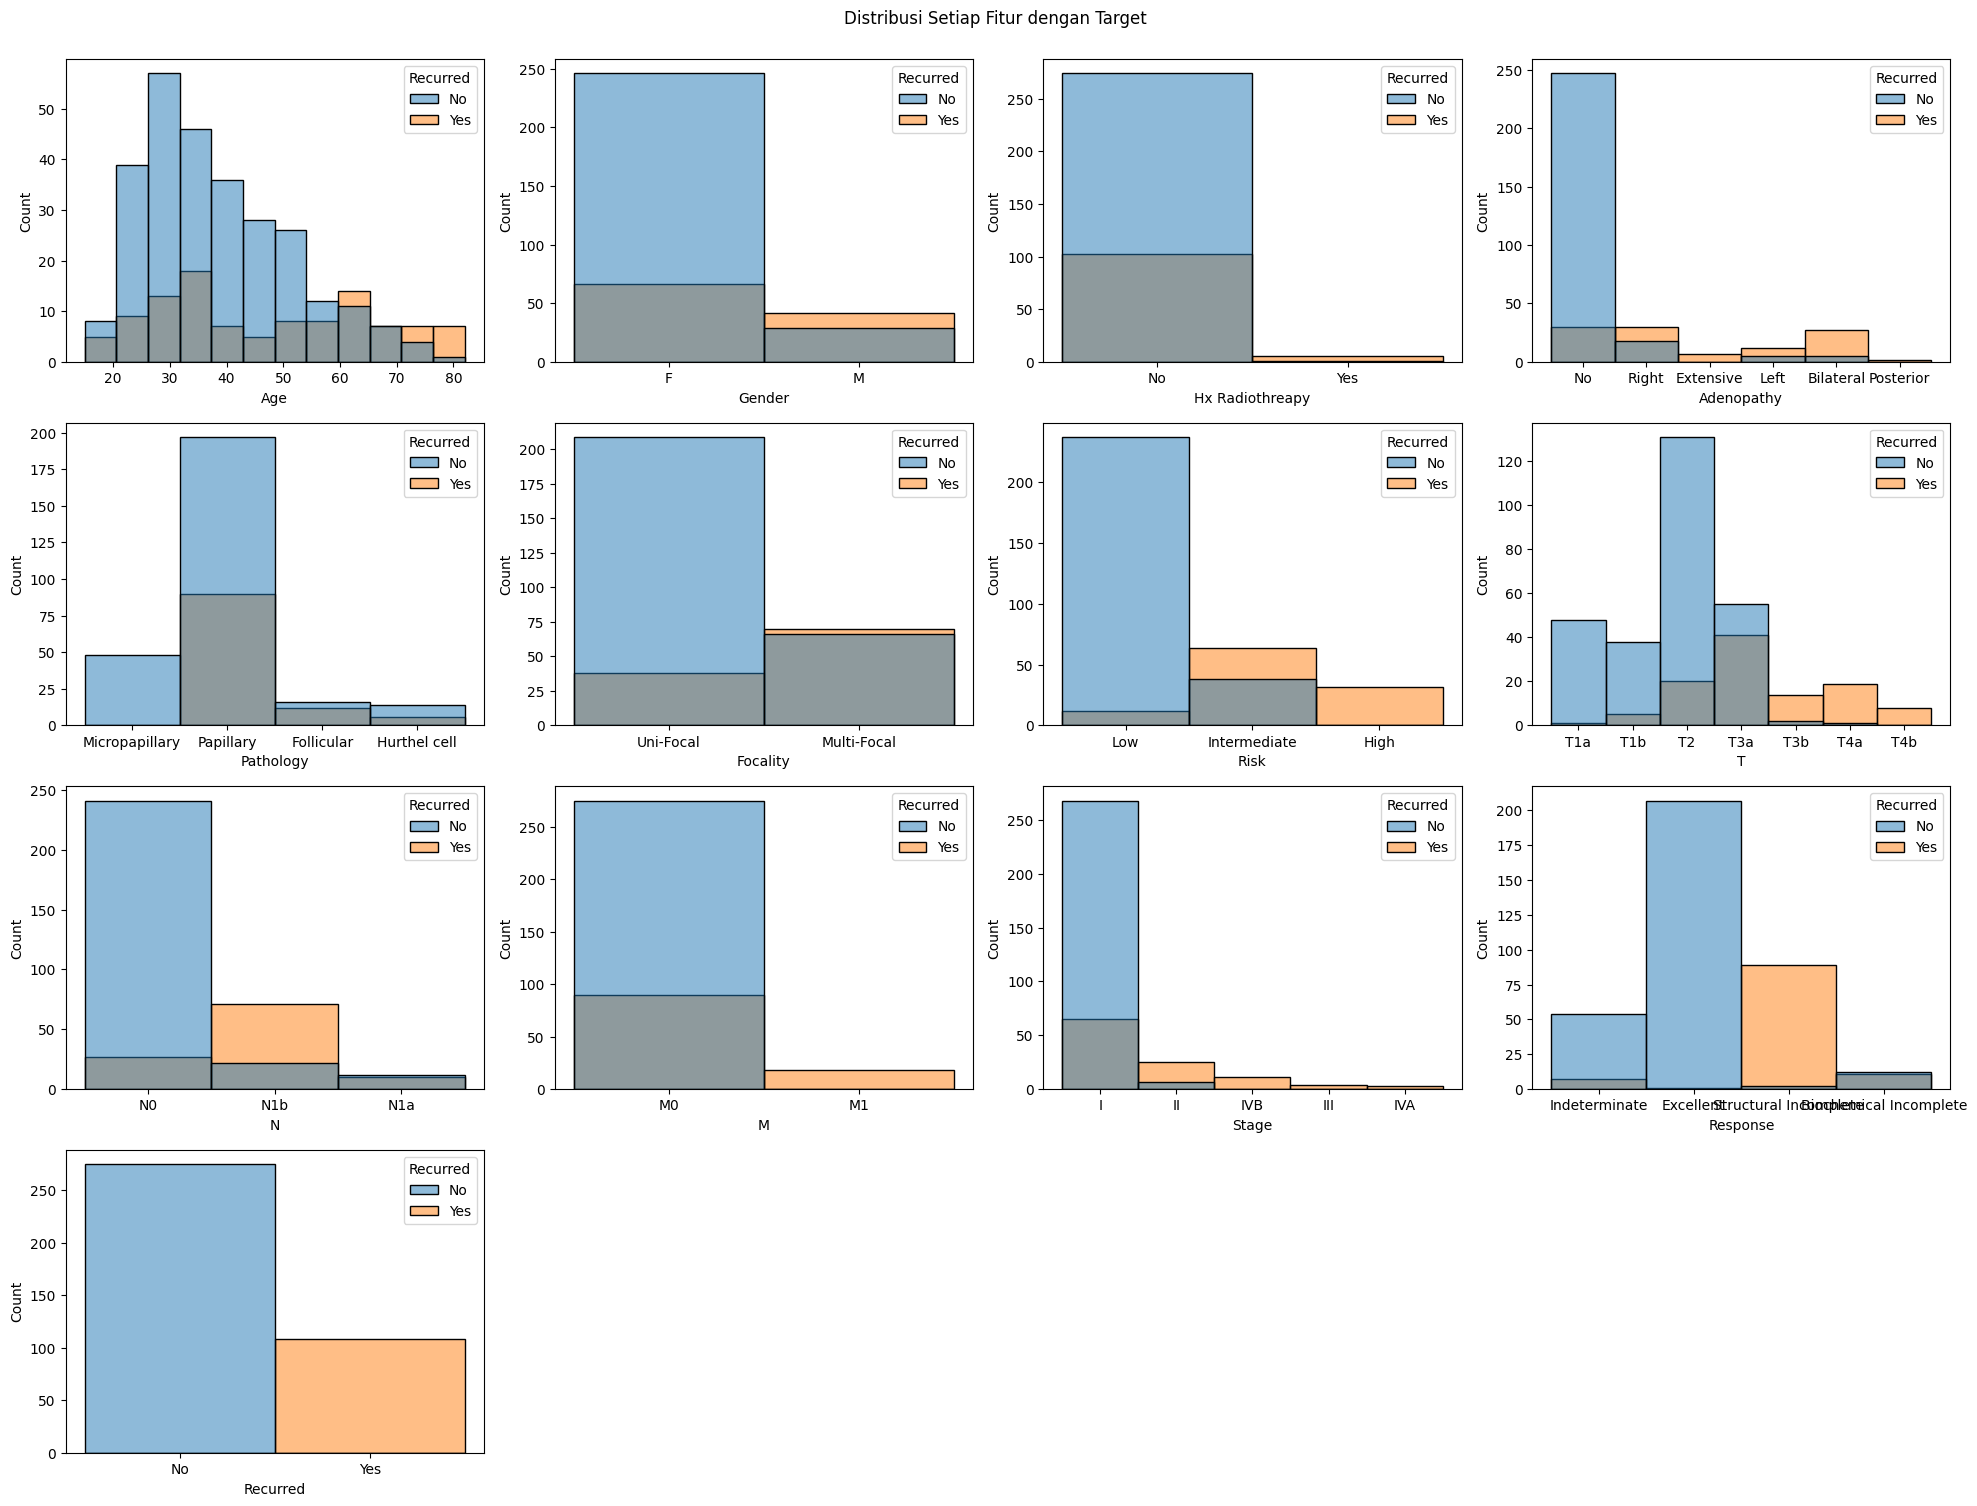

In [12]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(dataset):
    plt.subplot(4, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset["Recurred"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

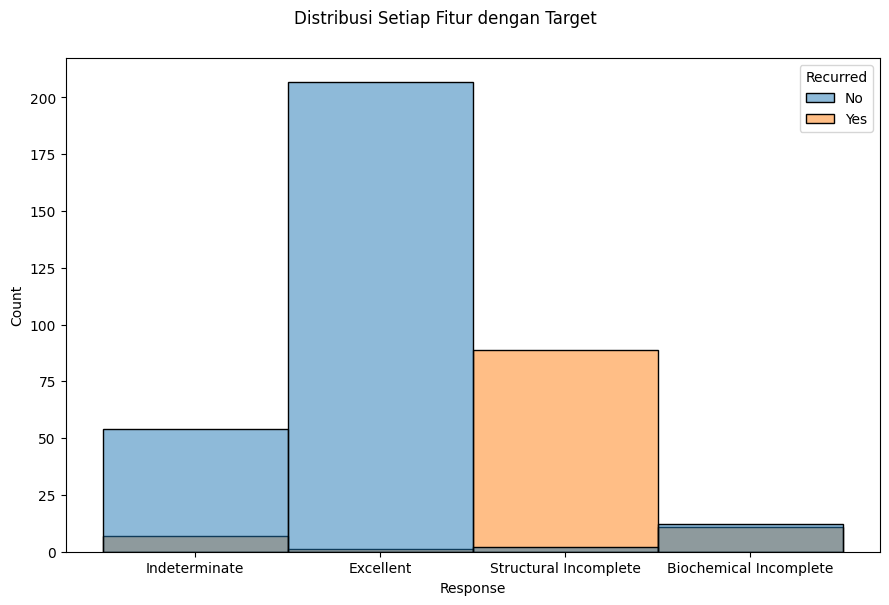

In [13]:
plt.figure(figsize=(9, 6))
sns.histplot(x=dataset["Response"], hue=dataset["Recurred"])

plt.suptitle("Distribusi Setiap Fitur dengan Target", y=1.001)
plt.tight_layout()
plt.show()

### 8. Dataset Sementara

#### *a. Copy Dataset Master*

In [14]:
dataset_copy = dataset.copy()

#### *b. Data Preprocessing*

Drop data duplikat

In [15]:
dataset_copy = dataset_copy.drop_duplicates()

Encode `Gender`

In [16]:
map_gender = {"M": 0, "F": 1}
dataset_copy["Gender"] = dataset_copy["Gender"].map(map_gender)

Encode `Hx Radiothreapy`

In [17]:
map_yes_no = {"No": 0, "Yes": 1}
dataset_copy["Hx Radiothreapy"] = dataset_copy["Hx Radiothreapy"].map(map_yes_no)

Encode `Adenopathy`

In [18]:
# map_adenopathy = {"No": 0, "Right": 1, "Left": 2, "Bilateral": 3, "Extensive": 4, "Posterior": 5}
map_adenopathy = (lambda x: 0 if x == 'No' else 1)
dataset_copy["Adenopathy"] = dataset_copy["Adenopathy"].map(map_adenopathy)

Encode `Pathology`

In [19]:
map_pathology = {"Micropapillary": 0, "Papillary": 1, "Follicular": 2, "Hurthel cell": 3}
dataset_copy["Pathology"] = dataset_copy["Pathology"].map(map_pathology)

Encode `Focality`

In [20]:
map_focality = {"Uni-Focal": 0, "Multi-Focal": 1}
dataset_copy["Focality"] = dataset_copy["Focality"].map(map_focality)

Encode `Risk`

In [21]:
map_risk = {"Low": 0, "Intermediate": 1, "High": 2}
dataset_copy["Risk"] = dataset_copy["Risk"].map(map_risk)

Encode `T`

In [22]:
map_t = {"T1a": 0, "T1b": 1, "T2": 2, "T3a": 3, "T3b": 4, "T4a": 5, "T4b": 6}
dataset_copy["T"] = dataset_copy["T"].map(map_t)

Encode `N`

In [23]:
map_n = {"N0": 0, "N1a": 1, "N1b": 2}
dataset_copy["N"] = dataset_copy["N"].map(map_n)

Encode `M`

In [24]:
map_m = {"M0": 0, "M1": 1}
dataset_copy["M"] = dataset_copy["M"].map(map_m)

Encode `Stage`

In [25]:
map_stage = {"I": 0, "II": 1, "III": 2, "IVA": 3, "IVB": 4}
dataset_copy["Stage"] = dataset_copy["Stage"].map(map_stage)

Encode `Response`

In [26]:
map_response = {"Excellent": 0, "Structural Incomplete": 1, "Indeterminate": 2, "Biochemical Incomplete": 3}
dataset_copy["Response"] = dataset_copy["Response"].map(map_response)

Encode Target

In [27]:
dataset_copy["Recurred"] = dataset_copy["Recurred"].map(map_yes_no)

#### *c. Data Transformation*

Membuat fitur baru `Spread Level`

In [28]:
dataset_copy["Spread Level"] = dataset_copy["T"] + dataset_copy["N"] + dataset_copy["M"]

Memasukkan fitur baru ke list kolom

In [29]:
all_feature_cols = ['Age', 'Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Spread Level']
categorical_cols = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Spread Level']

#### *d. Inspeksi Dataset Sementara Ulang*

In [30]:
dataset_copy

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred,Spread Level
0,27,1,0,0,0,0,0,0,0,0,0,2,0,0
1,34,1,0,0,0,0,0,0,0,0,0,0,0,0
2,30,1,0,0,0,0,0,0,0,0,0,0,0,0
3,62,1,0,0,0,0,0,0,0,0,0,0,0,0
4,62,1,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,0,1,1,1,0,2,6,2,1,4,3,1,9
379,81,0,1,1,1,1,2,6,2,1,4,1,1,9
380,72,0,0,1,1,1,2,6,2,1,4,1,1,9
381,61,0,1,1,3,1,2,6,2,0,3,1,1,8


In [31]:
dataset_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 382
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              330 non-null    int64
 1   Gender           330 non-null    int64
 2   Hx Radiothreapy  330 non-null    int64
 3   Adenopathy       330 non-null    int64
 4   Pathology        330 non-null    int64
 5   Focality         330 non-null    int64
 6   Risk             330 non-null    int64
 7   T                330 non-null    int64
 8   N                330 non-null    int64
 9   M                330 non-null    int64
 10  Stage            330 non-null    int64
 11  Response         330 non-null    int64
 12  Recurred         330 non-null    int64
 13  Spread Level     330 non-null    int64
dtypes: int64(14)
memory usage: 38.7 KB


### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [32]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

In [33]:
fitur = dataset_copy[all_feature_cols]
target = dataset_copy["Recurred"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)
mi_df

,Feature,Mutual Information
0,Age,2.311626
12,Spread Level,1.294923
11,Response,1.185417
6,Risk,1.053823
7,T,1.028659
5,Focality,0.939277
3,Adenopathy,0.908875
8,N,0.836311
10,Stage,0.788793
4,Pathology,0.765802


C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2098602569.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")


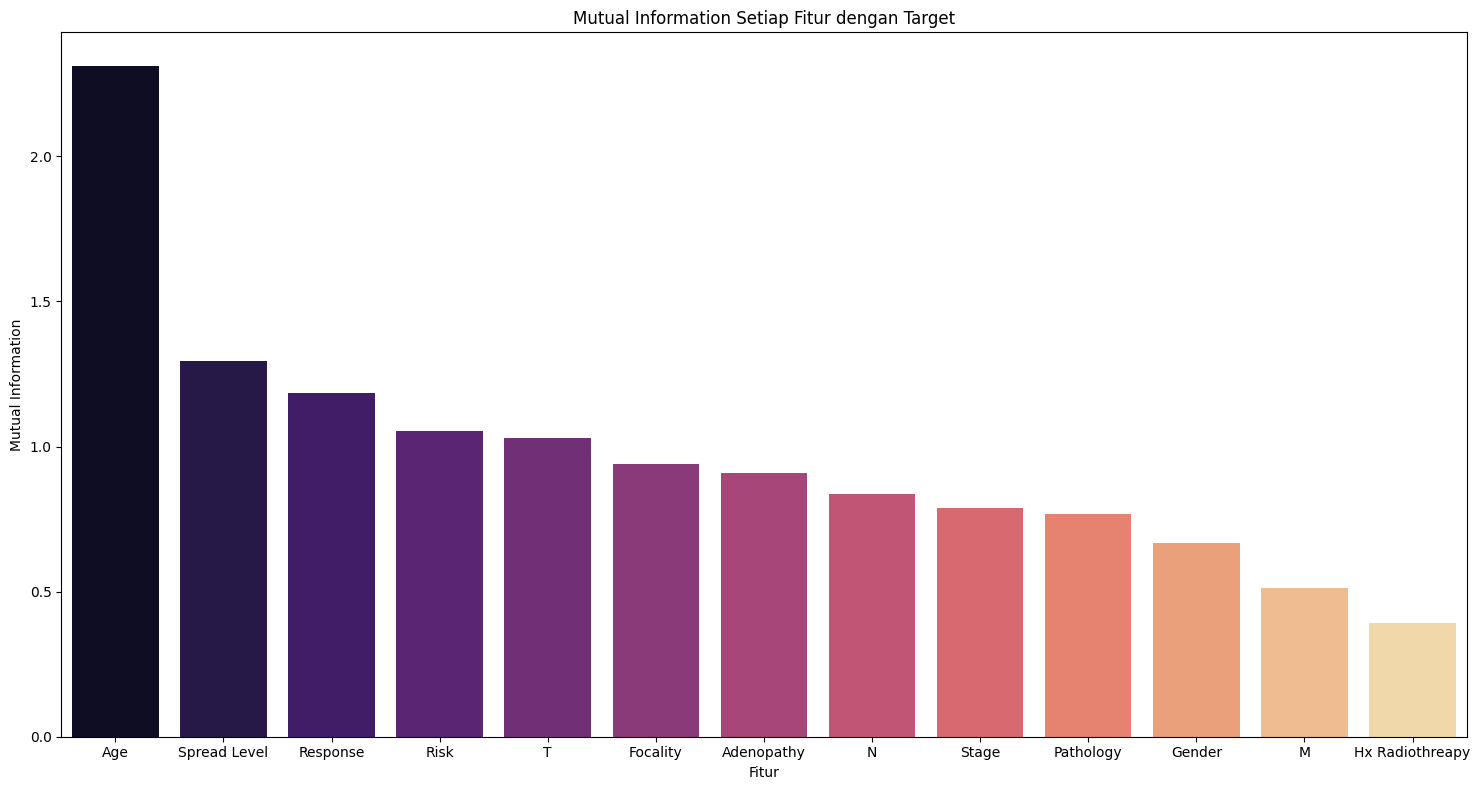

In [34]:
plt.figure(figsize=(15, 8))
sns.barplot(data=mi_df, x="Feature", y="Mutual Information", palette="magma")

plt.title("Mutual Information Setiap Fitur dengan Target")
plt.xlabel("Fitur")
plt.ylabel("Mutual Information")
plt.tight_layout()
plt.show()

#### *b. Kendall Method*

Fitur yang asli numerik hanya ada satu, dan itu numerik kontinu.

#### *c. Chi-square Method*

In [35]:
def chi_square_test(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])

    total = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / total
    chi_square = ((observed.values - expected) ** 2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)

    print(f"Feature: {col1} | Chi-square Score: {chi_square:.2f}")

    return chi_square, dof, observed, expected_df

chi_scores = []

for col in categorical_cols:
    chi, dof, observed, expected = chi_square_test(dataset_copy, col, 'Recurred')
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=["Feature", "Chi-Square Score"])
chi_df = chi_df.sort_values(by="Chi-Square Score", ascending=False)

Feature: Gender | Chi-square Score: 30.02
Feature: Hx Radiothreapy | Chi-square Score: 9.12
Feature: Adenopathy | Chi-square Score: 118.40
Feature: Pathology | Chi-square Score: 20.55
Feature: Focality | Chi-square Score: 36.91
Feature: Risk | Chi-square Score: 170.54
Feature: T | Chi-square Score: 111.72
Feature: N | Chi-square Score: 121.70
Feature: M | Chi-square Score: 39.13
Feature: Stage | Chi-square Score: 78.46
Feature: Response | Chi-square Score: 262.39
Feature: Spread Level | Chi-square Score: 168.42


C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\4011337335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")


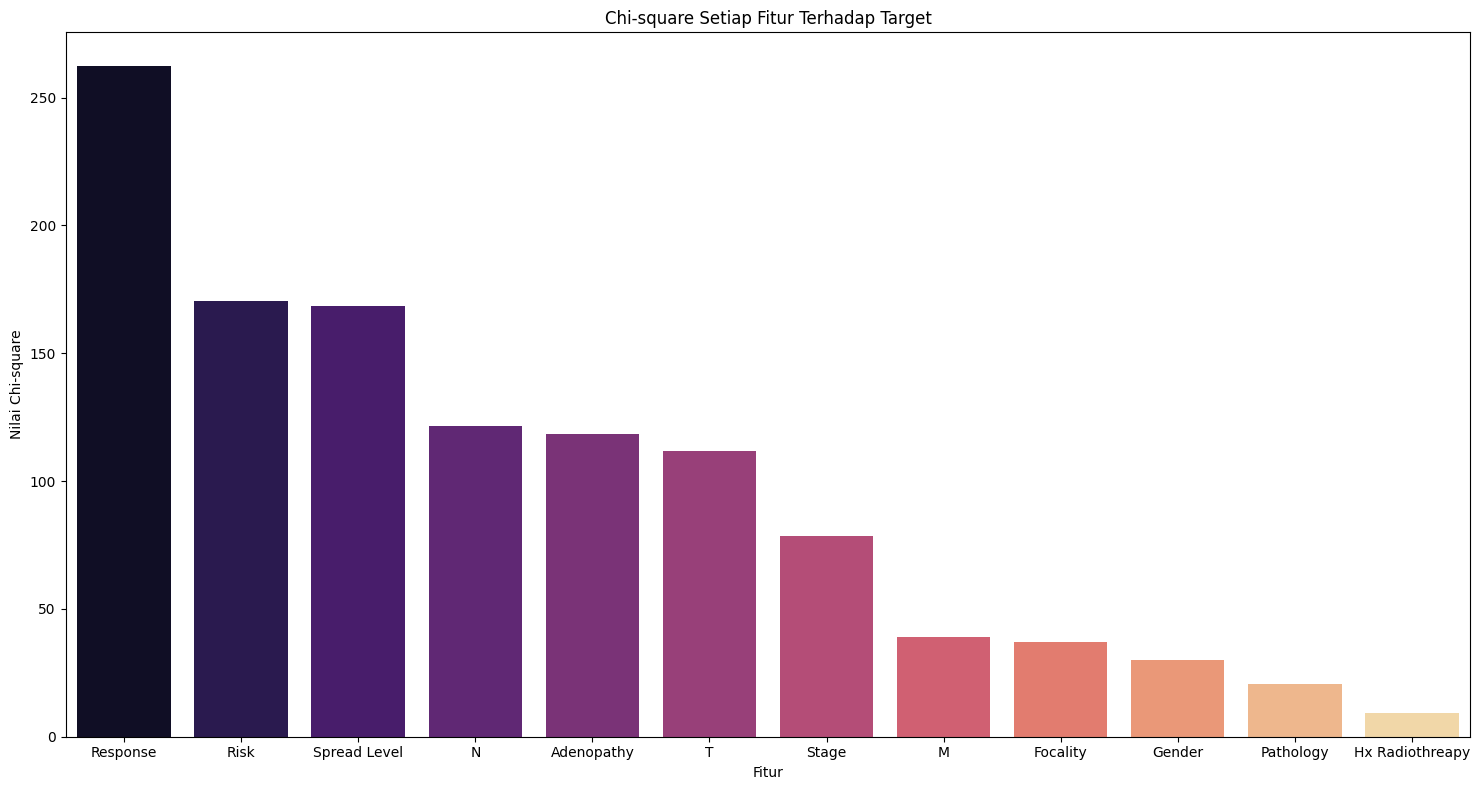

In [36]:
plt.figure(figsize=(15, 8))
sns.barplot(data=chi_df, x="Feature", y="Chi-Square Score", palette="magma")

plt.title("Chi-square Setiap Fitur Terhadap Target")
plt.xlabel("Fitur")
plt.ylabel("Nilai Chi-square")
plt.tight_layout()
plt.show()

### 11. Inspeksi Data Outlier

#### *a. Inspeksi Rentang Data*

In [37]:
def check_range(dataset, cols):
    for col in cols:
        data = dataset[col].dropna()
        
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_iqr = ((data < lower_bound) | (data > upper_bound)).sum()
        
        mean = data.mean()
        std = data.std()
        z_scores = (data - mean) / std
        outlier_z = (abs(z_scores) > 3).sum()

        print(f"Kolom: {col}")
        print("-" * 50)
        print(f"IQR Method:")
        print(f" - Q1: {Q1}")
        print(f" - Q3: {Q3}")
        print(f" - IQR: {IQR}")
        print(f" - Batas Bawah: {lower_bound}")
        print(f" - Batas Atas: {upper_bound}")
        print(f" - Jumlah outlier (IQR): {outlier_iqr}")
        print()
        
        print(f"Z-Score Method:")
        print(f" - Mean: {mean}")
        print(f" - Std Dev: {std}")
        print(f" - Jumlah outlier (Z-Score > 3): {outlier_z}")

check_range(dataset_copy, continu_cols)

Kolom: Age
--------------------------------------------------
IQR Method:
 - Q1: 30.0
 - Q3: 53.0
 - IQR: 23.0
 - Batas Bawah: -4.5
 - Batas Atas: 87.5
 - Jumlah outlier (IQR): 0

Z-Score Method:
 - Mean: 42.157575757575756
 - Std Dev: 15.62670596747566
 - Jumlah outlier (Z-Score > 3): 0


#### *b. Inspeksi Fitur Numerik dan Target*

<Axes: xlabel='Recurred', ylabel='Age'>

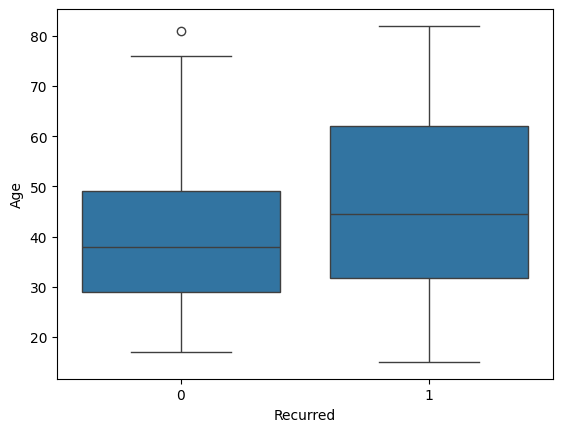

In [38]:
sns.boxplot(data=dataset_copy, x="Recurred", y="Age")

### 12. Kesimpulan Analisis

Setelah hasil analisis kami lakukan, ada beberapa hal yang bisa kami simpulkan:

1. Fitur yang berpengaruh adalah `Age`, `Spread Level`, dan `Response`
2. Menurut data yang diobservasi, pasien usia 50 ke atas sudah mulai memunculkan kecenderungan lebih tinggi untuk kambuh, dan tren makin jelas di usia 60 ke atas karena distribusi pasien kambuh makin mendominasi usia atasnya.
3. Pasien yang cenderung positif kanker tiroid adalah pasien dengan `Response` Structural Incomplete.

## ***B. Feature Selection***

In [39]:
feature_cols = all_feature_cols
# feature_cols = ["Age", "Spread Level", "Response"]
# feature_cols = ["Age", "Spread Level", "Response", "Risk", "T"]
# feature_cols = ['Age', 'Gender', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Spread Level']

## ***C. Data Preprocessing***

### 1. Drop Data Duplicated

In [40]:
dataset = dataset.drop_duplicates()

### 2. Data Encoding

Encode `Gender`

In [41]:
dataset["Gender"] = dataset["Gender"].map(map_gender)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2839456327.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Gender"] = dataset["Gender"].map(map_gender)


Encode `Hx Radiothreapy`

In [42]:
dataset["Hx Radiothreapy"] = dataset["Hx Radiothreapy"].map(map_yes_no)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\1986324219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Hx Radiothreapy"] = dataset["Hx Radiothreapy"].map(map_yes_no)


Encode `Adenopathy`

In [43]:
dataset["Adenopathy"] = dataset["Adenopathy"].map(map_adenopathy)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\3097803739.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Adenopathy"] = dataset["Adenopathy"].map(map_adenopathy)


Encode `Pathology`

In [44]:
dataset["Pathology"] = dataset["Pathology"].map(map_pathology)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\1761891789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Pathology"] = dataset["Pathology"].map(map_pathology)


Encode `Focality`

In [45]:
dataset["Focality"] = dataset["Focality"].map(map_focality)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\994785929.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Focality"] = dataset["Focality"].map(map_focality)


Encode `Risk`

In [46]:
dataset["Risk"] = dataset["Risk"].map(map_risk)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2008032032.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Risk"] = dataset["Risk"].map(map_risk)


Encode `T`

In [47]:
dataset["T"] = dataset["T"].map(map_t)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2924075398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["T"] = dataset["T"].map(map_t)


Encode `N`

In [48]:
dataset["N"] = dataset["N"].map(map_n)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2867336928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["N"] = dataset["N"].map(map_n)


Encode `M`

In [49]:
dataset["M"] = dataset["M"].map(map_m)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\3381312363.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["M"] = dataset["M"].map(map_m)


Encode `Stage`

In [50]:
dataset["Stage"] = dataset["Stage"].map(map_stage)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\3362067344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Stage"] = dataset["Stage"].map(map_stage)


Encode `Response`

In [51]:
dataset["Response"] = dataset["Response"].map(map_response)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\1855625173.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Response"] = dataset["Response"].map(map_response)


Encode Target

In [52]:
dataset["Recurred"] = dataset["Recurred"].map(map_yes_no)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\2589914331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Recurred"] = dataset["Recurred"].map(map_yes_no)


### 3. Inspeksi Ulang Dataset

In [53]:
dataset

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,1,0,0,0,0,0,0,0,0,0,2,0
1,34,1,0,0,0,0,0,0,0,0,0,0,0
2,30,1,0,0,0,0,0,0,0,0,0,0,0
3,62,1,0,0,0,0,0,0,0,0,0,0,0
4,62,1,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,0,1,1,1,0,2,6,2,1,4,3,1
379,81,0,1,1,1,1,2,6,2,1,4,1,1
380,72,0,0,1,1,1,2,6,2,1,4,1,1
381,61,0,1,1,3,1,2,6,2,0,3,1,1


In [54]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 382
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              330 non-null    int64
 1   Gender           330 non-null    int64
 2   Hx Radiothreapy  330 non-null    int64
 3   Adenopathy       330 non-null    int64
 4   Pathology        330 non-null    int64
 5   Focality         330 non-null    int64
 6   Risk             330 non-null    int64
 7   T                330 non-null    int64
 8   N                330 non-null    int64
 9   M                330 non-null    int64
 10  Stage            330 non-null    int64
 11  Response         330 non-null    int64
 12  Recurred         330 non-null    int64
dtypes: int64(13)
memory usage: 36.1 KB


## ***D. Data Transformation***

### 1. Feature Engineering

In [55]:
dataset["Spread Level"] = dataset["T"] + dataset["N"] + dataset["M"]

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\3956683531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Spread Level"] = dataset["T"] + dataset["N"] + dataset["M"]


## ***E. Splitting Dataset***

In [56]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42, frac=1):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=frac, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "Recurred")

## ***F. Sampling Data***

In [57]:
def random_oversample(dataset, target_column, additional_size = None):

    resampled_data = [dataset]
    classes = dataset[target_column].value_counts()

    for label, size in classes.items():
        if additional_size and additional_size.get(label, 0):
            additional_data = dataset[dataset[target_column] == label]
            minority_class_data = additional_data.sample(n = additional_size[label], replace = True,random_state = 42)
            resampled_data.append(minority_class_data)

    final_dataset = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)
    return final_dataset

## ***G. Feature Target Declaration***

In [58]:
X_train = dataset_training[feature_cols]
X_test = dataset_testing[feature_cols]

y_train = dataset_training["Recurred"]
y_test = dataset_testing["Recurred"]

## ***H. Dimension Reduction***

So that the code knows which is categorical which is not

In [59]:
X_train['Age'] = X_train['Age'].astype(float)
X_test['Age'] = X_test['Age'].astype(float)

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\461709556.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Age'] = X_train['Age'].astype(float)
C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\461709556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Age'] = X_test['Age'].astype(float)


In [60]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              263 non-null    float64
 1   Gender           263 non-null    int64  
 2   Hx Radiothreapy  263 non-null    int64  
 3   Adenopathy       263 non-null    int64  
 4   Pathology        263 non-null    int64  
 5   Focality         263 non-null    int64  
 6   Risk             263 non-null    int64  
 7   T                263 non-null    int64  
 8   N                263 non-null    int64  
 9   M                263 non-null    int64  
 10  Stage            263 non-null    int64  
 11  Response         263 non-null    int64  
 12  Spread Level     263 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 26.8 KB


### 1. Principal Component Analysis

In [61]:
def pca_fit(X, n_components):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_std[X_std == 0] = 1 
    
    X_scaled = (X - X_mean) / X_std

    cov = np.cov(X_scaled, rowvar=False)

    if np.ndim(cov) == 0:
        cov = np.array([[cov]])

    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sorted_indices]
    eigenvectors = eigenvectors[:, sorted_indices]

    components = eigenvectors[:, :n_components]
    X_pca = np.dot(X_scaled, components)
    explained_variance = eigenvalues[:n_components]

    return X_pca, components, X_mean, X_std, explained_variance


### 2. Multiple Correspondence Analysis

In [62]:
def mca_fit(X_cat, n_components):
    X_dummies = pd.get_dummies(X_cat)
    X_matrix = X_dummies.to_numpy()
    
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)

    U, S, VT = np.linalg.svd(Z, full_matrices=False)
    X_mca = U[:, :n_components] * S[:n_components]
    components = VT[:n_components, :]
    
    return X_mca, components, X_dummies.columns

def mca_transform(X_cat, components, dummy_columns):
    X_dummies = pd.get_dummies(X_cat)
    X_dummies = X_dummies.reindex(columns=dummy_columns, fill_value=0)
    
    X_matrix = X_dummies.to_numpy()
    row_sums = X_matrix.sum(axis=1, keepdims=True)
    col_sums = X_matrix.sum(axis=0, keepdims=True)
    total = X_matrix.sum()
    expected = row_sums @ col_sums / total
    Z = (X_matrix - expected) / np.sqrt(expected)
    
    X_proj = Z @ components.T
    return X_proj

### 3. Factor Analysis of Mixed Data

In [63]:
def famd_fit(df, n_components):
    float_cols = df.select_dtypes(include = ['float']).columns
    int_cols = df.select_dtypes(include = ['int']).columns

    X_num = df[float_cols].to_numpy()
    X_pca, pca_components, pca_mean, pca_std, _ = pca_fit(X_num, X_num.shape[1])

    X_cat = df[int_cols]
    X_mca, mca_components, dummy_columns = mca_fit(X_cat, min(n_components, 50))

    X_combined = np.hstack([X_pca, X_mca])
    X_famd, famd_components, _, _, _ = pca_fit(X_combined, n_components)

    return {
        'float_cols' : float_cols,
        'int_cols' : int_cols,
        'X_pca' : X_pca,
        'pca_components' : pca_components,
        'pca_mean' : pca_mean,
        'pca_std' : pca_std,
        'X_mca' : X_mca,
        'mca_components' : mca_components,
        'dummy_columns' : dummy_columns,
        'X_famd' : X_famd,
        'famd_components' : famd_components
    }

def famd_transform(df, model):
    X_num = df[model['float_cols']].to_numpy()
    safe_std = np.where(model['pca_std'] == 0, 1, model['pca_std'])
    X_scaled = (X_num - model['pca_mean']) / safe_std
    X_pca = np.dot(X_scaled, model['pca_components'])

    X_cat = df[model['int_cols']]
    X_mca = mca_transform(X_cat, model['mca_components'], model['dummy_columns'])

    X_combined = np.hstack([X_pca, X_mca])
    X_famd = np.dot((X_combined - np.mean(X_combined, axis=0)) / np.std(X_combined, axis = 0), model['famd_components']) 

    return X_famd

In [ ]:
model_famd = famd_fit(X_train, n_components=2)
X_train_famd = model_famd['X_famd']
X_test_famd = famd_transform(X_test, model_famd)

famd_df = pd.DataFrame(X_train_famd, columns=['Dim 1', 'Dim 2'])
famd_df['target'] = y_train.values

C:\Users\nizam\AppData\Local\Temp\ipykernel_9604\3164405436.py:10: RuntimeWarning: invalid value encountered in divide
  Z = (X_matrix - expected) / np.sqrt(expected)


LinAlgError: SVD did not converge

### 4. Visualisasi Data Training Setelah FAMD

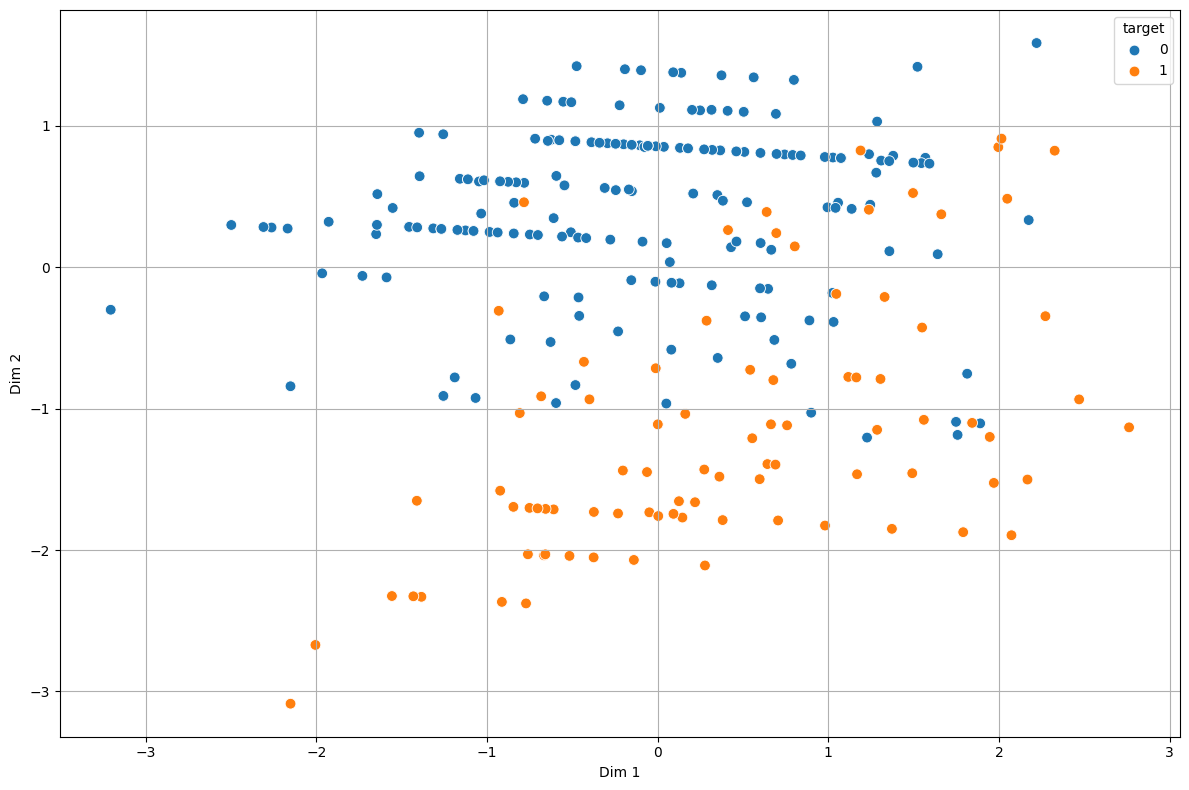

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(famd_df, x="Dim 1", y="Dim 2", hue='target', palette='tab10', s = 60)

plt.grid(True)
plt.tight_layout()
plt.show()

# **III. Modeling**

## ***A. Model Application***

### 1. Model dengan Class

In [ ]:
class KNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def minkowski_distance(self, a, b):
        return np.sum(np.abs(a - b) ** self.p) ** (1 / self.p)
    
    def predict(self, X):
        X_test = X
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))

        for i, test_point in enumerate(X_test):
            for j, train_point in enumerate(self.X_train):
                distances[i, j] = self.minkowski_distance(test_point, train_point)

        nearest_neighbors_indices = np.argsort(distances, axis=1)[:, :self.k]
        neighbors = np.array(self.y_train)[nearest_neighbors_indices]

        y_pred = []
        for neighbor_classes in neighbors:
            classes, counts = np.unique(neighbor_classes, return_counts=True)
            predicted_classes = classes[np.argmax(counts)]
            y_pred.append(predicted_classes)

        return np.array(y_pred)

    def plot_neighbor(self, input_point, y_train, zoom=False):
        distances = np.array([self.minkowski_distance(input_point, train_point) for train_point in self.X_train])
        nearest_neighbors_indices = np.argsort(distances)[:self.k]

        plt.figure(figsize=(12, 8))
        scatter = plt.scatter(self.X_train[:, 0], self.X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.7, label="Training Data")
        plt.colorbar(scatter, label="Class")

        plt.scatter(input_point[0], input_point[1], c="yellow", edgecolors="black", s=250, marker="*", label="Input Data")

        if zoom:
            all_x = [input_point[0]] + [self.X_train[idx][0] for idx in nearest_neighbors_indices]
            all_y = [input_point[1]] + [self.X_train[idx][1] for idx in nearest_neighbors_indices]

            x_padding = (max(all_x) - min(all_x)) * 0.2
            y_padding = (max(all_y) - min(all_y)) * 0.2

            offset_y = y_padding * 0.15

            plt.xlim(min(all_x) - x_padding, max(all_x) + x_padding)
            plt.ylim(min(all_y) - y_padding, max(all_y) + y_padding)

            print("Label Tetangga Terdekat:")
            for i, idx in enumerate(nearest_neighbors_indices):
                print(f"Tetangga ke-{i+1}: Label = {y_train[idx]}")
        
        else:
            offset_y = 0.2
        
        cmap = plt.cm.coolwarm
        norm = plt.Normalize(vmin=0, vmax=1)

        for i, idx in enumerate(nearest_neighbors_indices):
            neighbor_point = self.X_train[idx]
            color = cmap(norm(y_train[idx])) 
            label = "Nearest Neighbors" if i == 0 else None
            plt.scatter(neighbor_point[0], neighbor_point[1], facecolors=color, edgecolors="black", 
                        s=75, linewidth=2, label=label)
            plt.plot([input_point[0], neighbor_point[0]], 
                     [input_point[1], neighbor_point[1]], 
                     "black", linestyle="dashed", alpha=0.5)
            plt.text(neighbor_point[0], neighbor_point[1] + offset_y, f"{i+1}", fontsize=9, color="black", ha="center")

        plt.xlabel("Dim 1 (FAMD)")
        plt.ylabel("Dim 2 (FAMD)")
        plt.title("FAMD Scatter Plot dengan Input Data Baru")
        plt.legend()
        plt.grid(True)
        plt.show()

### 2. Rule of Thumb

In [ ]:
rule_of_thumb = round(np.sqrt(len(X_train_famd)))
rule_of_thumb

16

### 3. K Cross Validation

#### *a. Manhattan Distance*

In [ ]:
k_values1 = range(1, 11)
train_accs1 = []
test_accs1 = []

for k in k_values1:
    model = KNN(k=k, p=1)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc1 = np.mean(y_pred_train == y_train) * 100
    test_acc1 = np.mean(y_pred_test == y_test) * 100

    train_accs1.append(train_acc1)
    test_accs1.append(test_acc1)

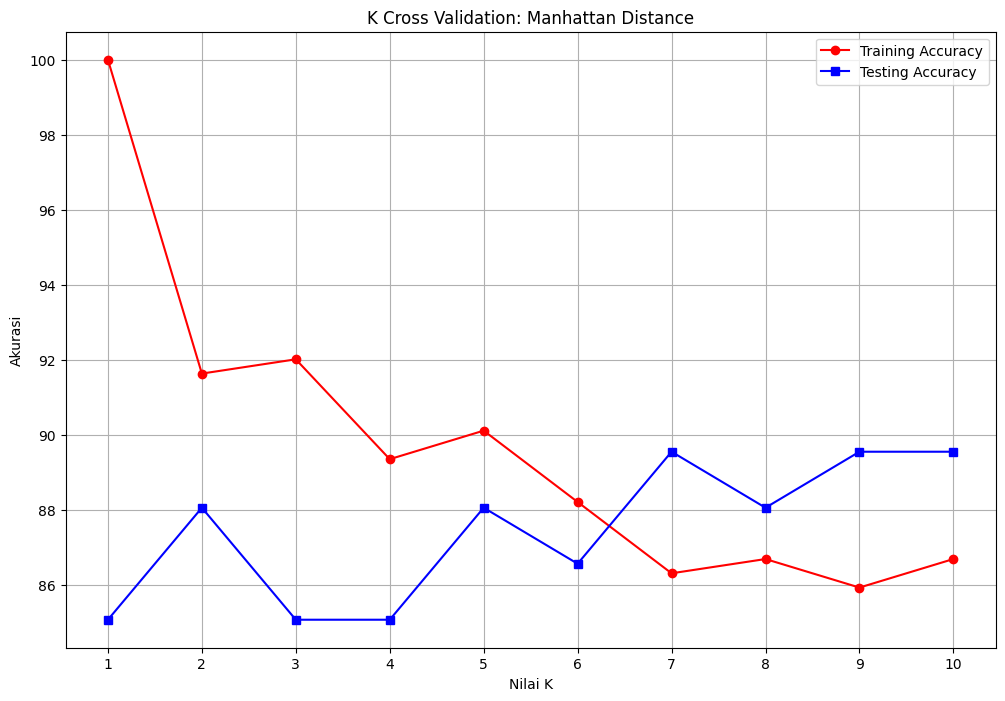

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(k_values1, train_accs1, marker="o", color="red", label="Training Accuracy")
plt.plot(k_values1, test_accs1, marker="s", color="blue", label="Testing Accuracy")
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.title("K Cross Validation: Manhattan Distance")
plt.xticks(k_values1)
plt.legend()
plt.grid()
plt.show()

#### *b. Euclidean Distance*

In [ ]:
train_accs2 = []
test_accs2 = []

for k in k_values1:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred_train = model.predict(X_train_famd)
    y_pred_test = model.predict(X_test_famd)

    train_acc2 = np.mean(y_pred_train == y_train) * 100
    test_acc2 = np.mean(y_pred_test == y_test) * 100

    train_accs2.append(train_acc2)
    test_accs2.append(test_acc2)

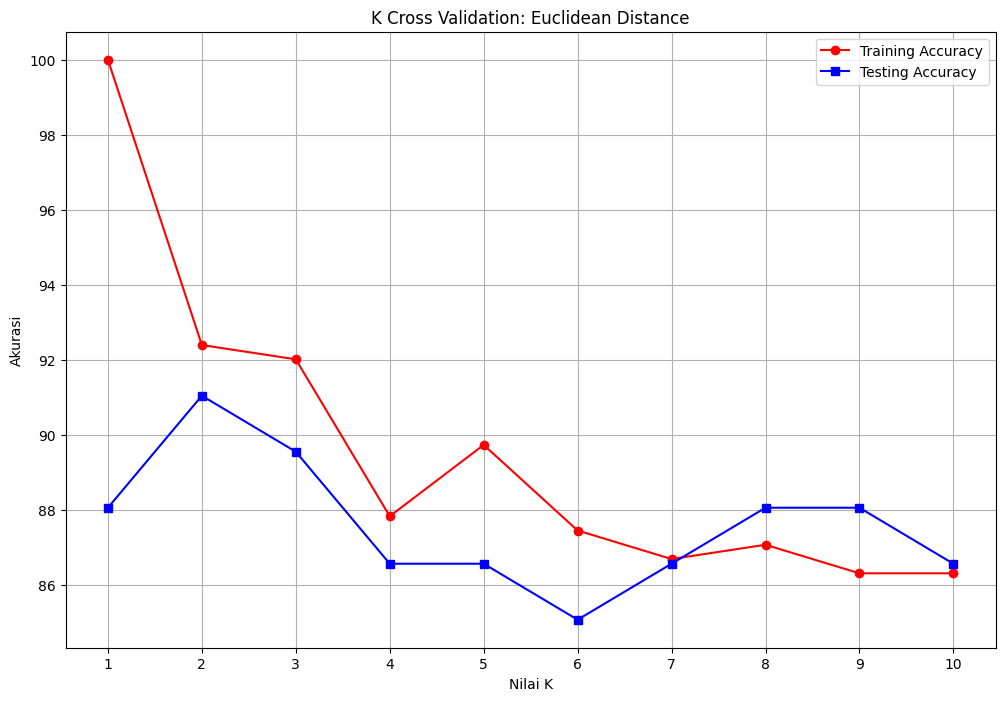

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(k_values1, train_accs2, marker="o", color="red", label="Training Accuracy")
plt.plot(k_values1, test_accs2, marker="s", color="blue", label="Testing Accuracy")
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.title("K Cross Validation: Euclidean Distance")
plt.xticks(k_values1)
plt.legend()
plt.grid()
plt.show()

### 4. Elbow Method

#### *a. Manhattan Distance*

In [ ]:
def error_rate(y_true, y_pred):
    return np.sum(y_true != y_pred) / len(y_true)

k_values2 = range(5, 11)
errors1 = []

for k in k_values2:
    model = KNN(k=k, p=1)
    model.fit(X_train_famd, y_train)
    y_pred = model.predict(X_test_famd)
    error1 = error_rate(y_test, y_pred)
    errors1.append(error1)

C:\Users\nizam\AppData\Local\Temp\ipykernel_19588\1564688295.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


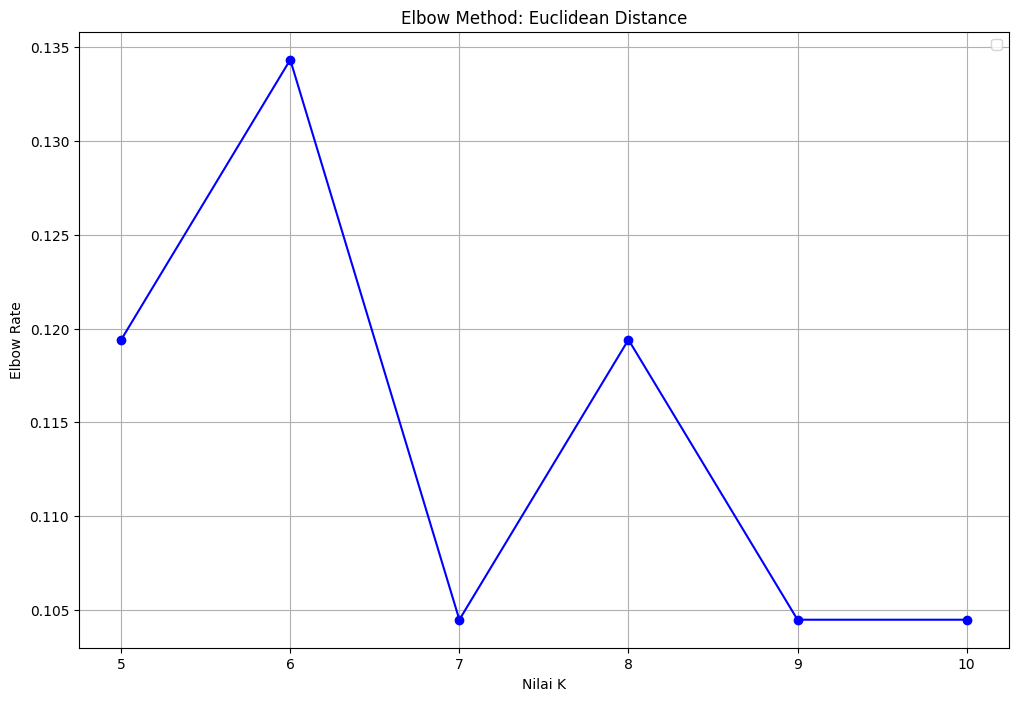

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(k_values2, errors1, marker="o", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Elbow Rate")
plt.title("Elbow Method: Euclidean Distance")
plt.xticks(k_values2)
plt.legend()
plt.grid()
plt.show()

#### *b. Euclidean Distance*

In [ ]:
k_values2 = range(4, 11)
errors2 = []

for k in k_values2:
    model = KNN(k=k, p=2)
    model.fit(X_train_famd, y_train)
    y_pred = model.predict(X_test_famd)
    error2 = error_rate(y_test, y_pred)
    errors2.append(error2)

C:\Users\nizam\AppData\Local\Temp\ipykernel_19588\717977771.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


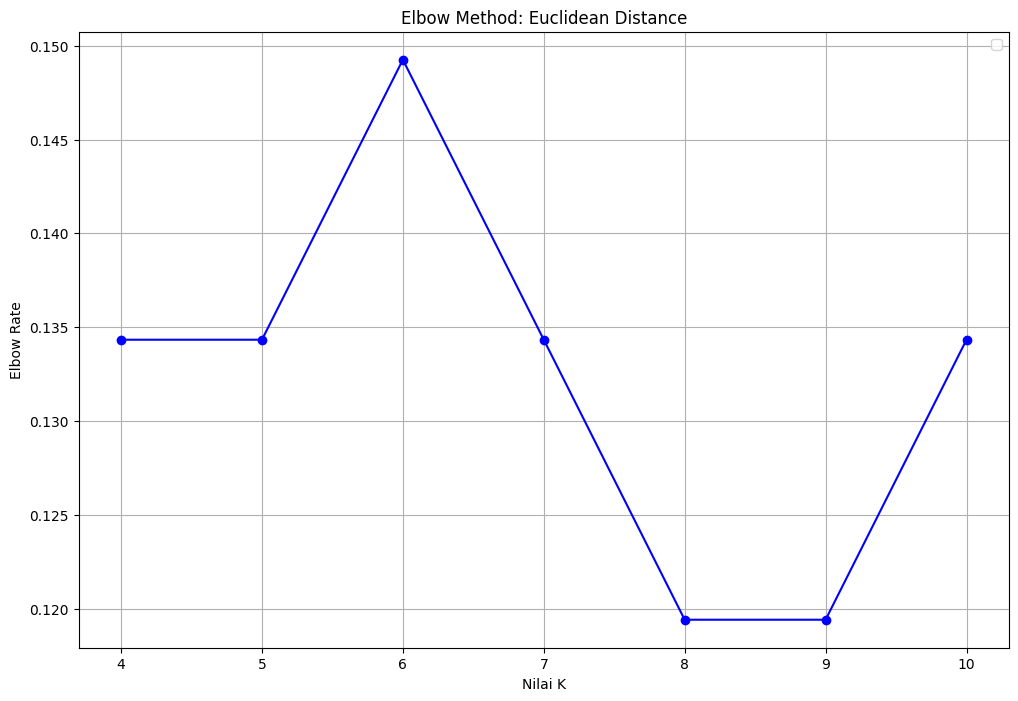

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(k_values2, errors2, marker="o", color="blue")
plt.xlabel("Nilai K")
plt.ylabel("Elbow Rate")
plt.title("Elbow Method: Euclidean Distance")
plt.xticks(k_values2)
plt.legend()
plt.grid()
plt.show()

### 5. Pengaplikasian Model

- `Top 3 Feature`: (k=7, p=1), (k=9, p=2)

- `Top 5 Feature`: (k=7, p=1), (k=7, p=2)
- `All Feature`: (k=5, p=1), (k=7, p=2)

#### *a. Manhattan Distance*

In [ ]:
model1 = KNN(k=5, p=1)
model1.fit(X_train_famd, y_train)
y_pred_train1 = model1.predict(X_train_famd)
y_pred_test1 = model1.predict(X_test_famd)

#### *b. Euclidean Distance*

In [ ]:
model2 = KNN(k=7, p=2)
model2.fit(X_train_famd, y_train)
y_pred_train2 = model2.predict(X_train_famd)
y_pred_test2 = model2.predict(X_test_famd)

## ***B. Visualisasi Model***

### 1. Uji Coba Data Baru

#### *a. Input Data*

In [ ]:
feature_cols

['Age',
 'Gender',
 'Hx Radiothreapy',
 'Adenopathy',
 'Pathology',
 'Focality',
 'Risk',
 'T',
 'N',
 'M',
 'Stage',
 'Response',
 'Spread Level']

In [ ]:
all_fitur_input_data = [
    58, 
    1, 
    1,
    1, 
    1, 
    1, 
    2, 
    3, 
    1, 
    0, 
    2, 
    2, 
    4
    ]

top5_input = [58, 4, 2, 2, 3]

top3_input = [58, 4, 2]

input_df = pd.DataFrame([all_fitur_input_data], columns=feature_cols)
input_famd = famd_transform_auto(input_df, famd_model)[0]

In [ ]:
input_famd

array([-4.15015786,  2.89535058])

#### *b. Manhattan Distance*

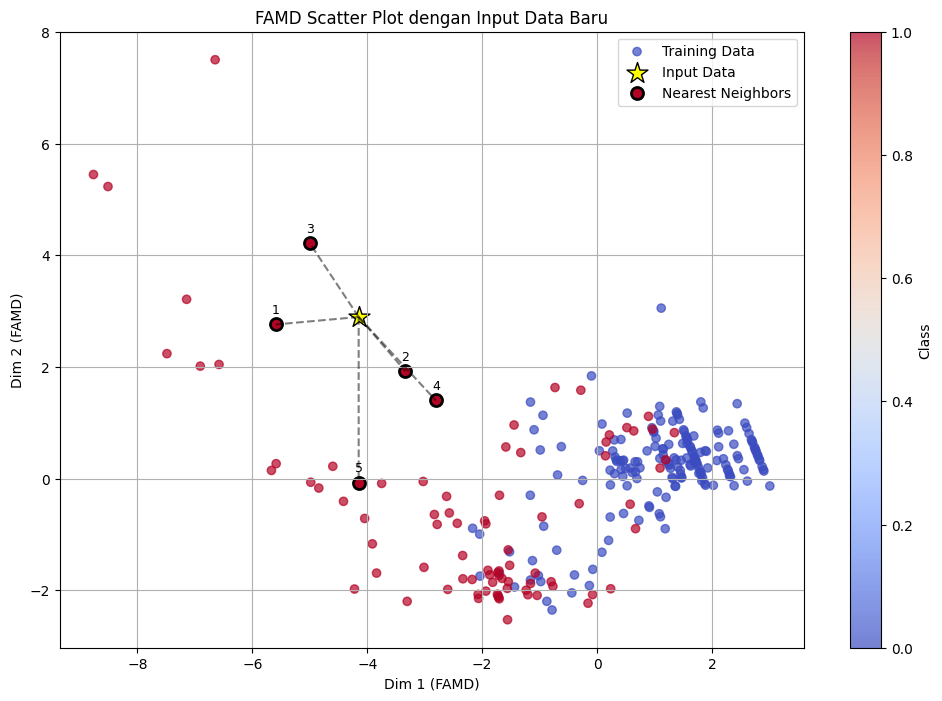

In [ ]:
model1.plot_neighbor(input_famd, y_train, zoom=False)

Label Tetangga Terdekat:
Tetangga ke-1: Label = 1
Tetangga ke-2: Label = 1
Tetangga ke-3: Label = 1
Tetangga ke-4: Label = 1
Tetangga ke-5: Label = 1


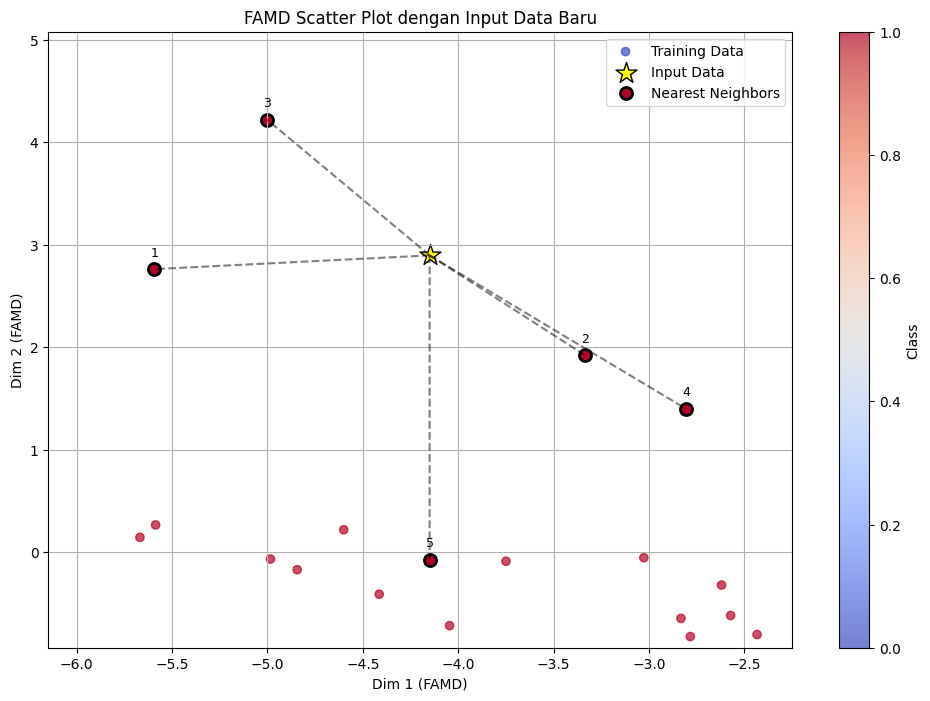

In [ ]:
model1.plot_neighbor(input_famd, y_train, zoom=True)

#### *c. Euclidean Distance*

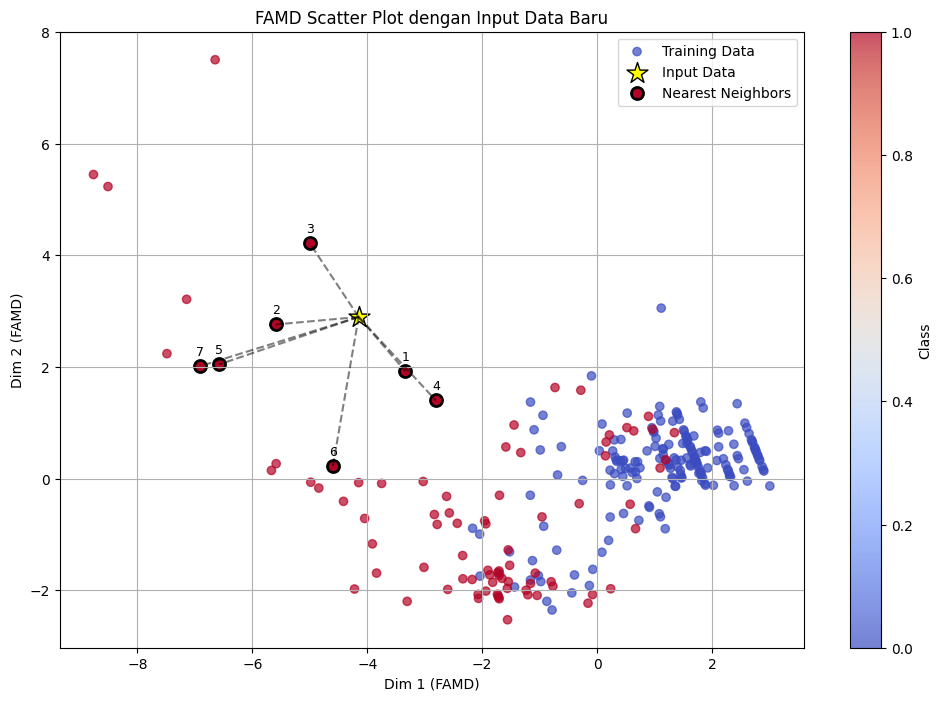

In [ ]:
model2.plot_neighbor(input_famd, y_train, zoom=False)

Label Tetangga Terdekat:
Tetangga ke-1: Label = 1
Tetangga ke-2: Label = 1
Tetangga ke-3: Label = 1
Tetangga ke-4: Label = 1
Tetangga ke-5: Label = 1
Tetangga ke-6: Label = 1
Tetangga ke-7: Label = 1


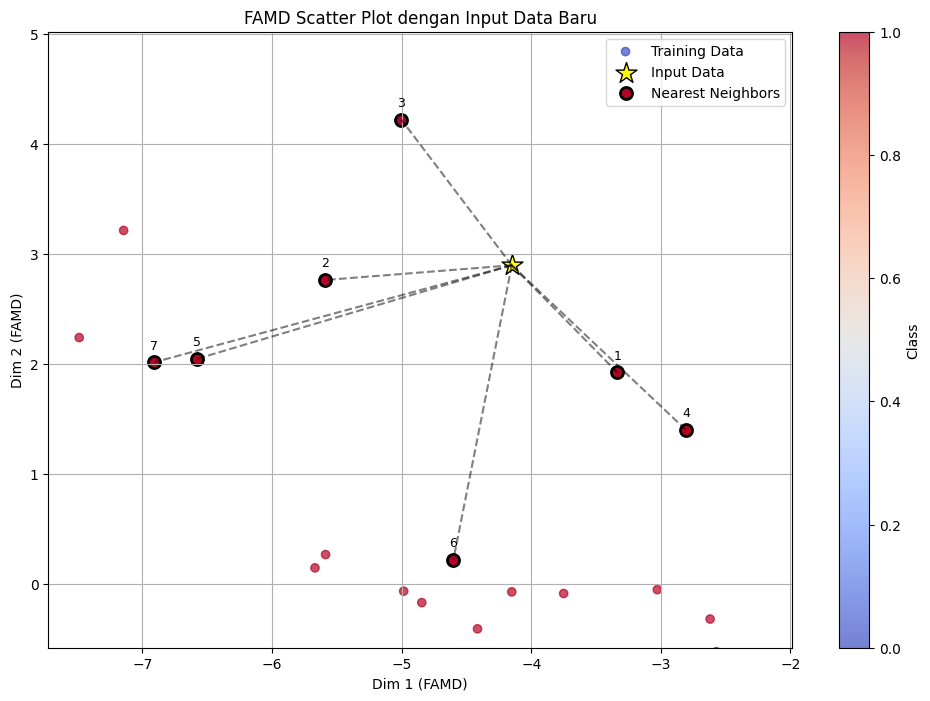

In [ ]:
model2.plot_neighbor(input_famd, y_train, zoom=True)

### 2. Distribusi Hasil Predksi

#### *a. Training Model*

In [ ]:
data_pred_train = pd.DataFrame({
    "Manhattan Train": y_pred_train1,
    "Euclidean Train": y_pred_train2,
    "Aktual Training": y_train
})

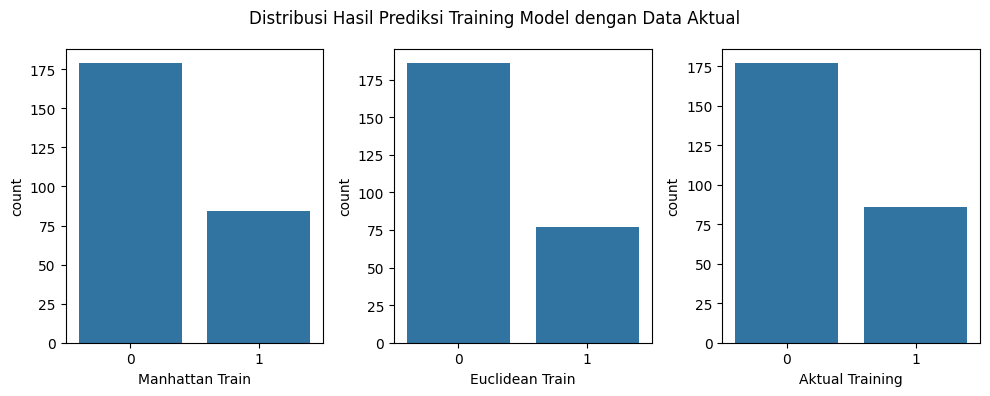

In [ ]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(data_pred_train):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_train[col])

plt.suptitle("Distribusi Hasil Prediksi Training Model dengan Data Aktual")
plt.tight_layout()
plt.show()

#### *b. Testing Model*

In [ ]:
data_pred_test = pd.DataFrame({
    "Manhattan Test": y_pred_test1,
    "Euclidean Test": y_pred_test2,
    "Aktual Test": y_test
})

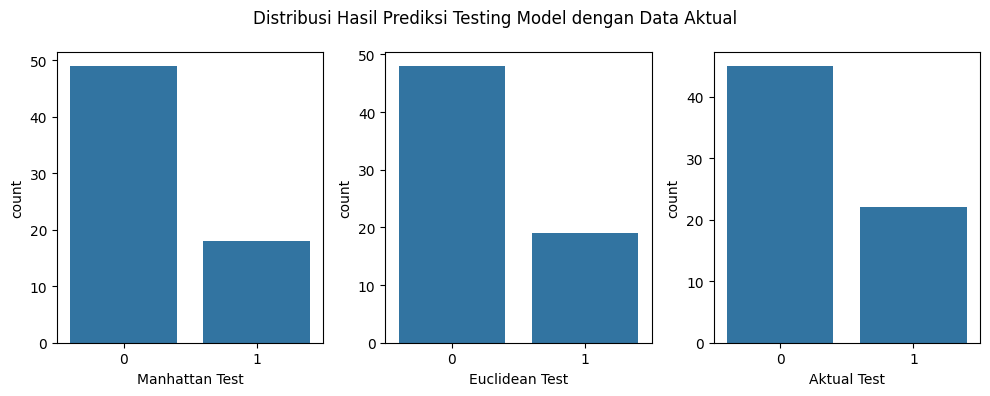

In [ ]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(data_pred_test):
    plt.subplot(1, 3, i+1)
    sns.countplot(x=data_pred_test[col])

plt.suptitle("Distribusi Hasil Prediksi Testing Model dengan Data Aktual")
plt.tight_layout()
plt.show()

### 4. Confusion Matrix

#### *a. Manhattan Distance*

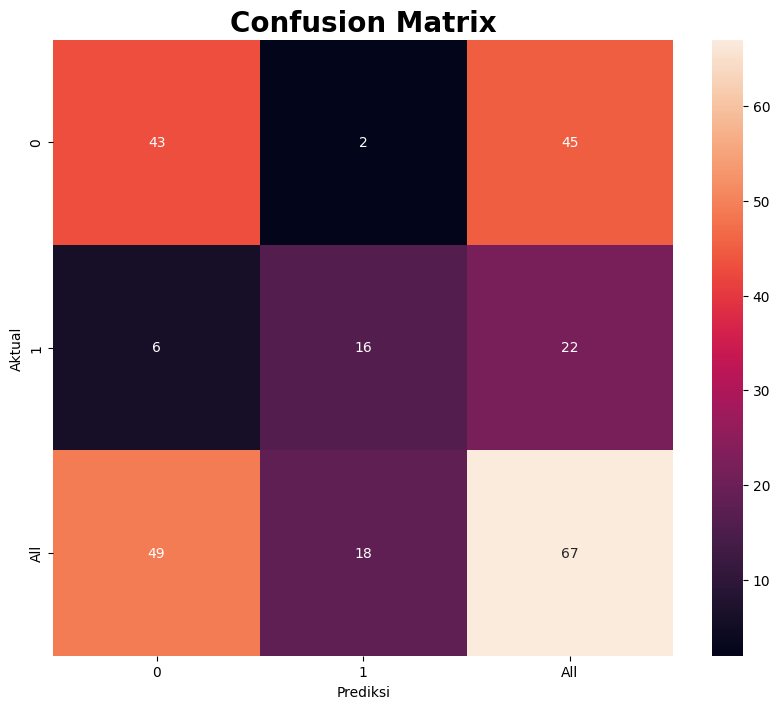

,0,1,All
0,43,2,45
1,6,16,22
All,49,18,67


In [ ]:
data_confusion = pd.crosstab(y_test, y_pred_test1, margins=True)
data_confusion.columns = data_confusion.columns.tolist()
data_confusion.index = data_confusion.index.tolist()
    
plt.figure(figsize=(10, 8))
plt.title('Confusion Matrix', size=20, weight='bold')
sns.heatmap(data_confusion, annot=True, fmt='d')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

display(data_confusion)

#### *b. Euclidean Distance*

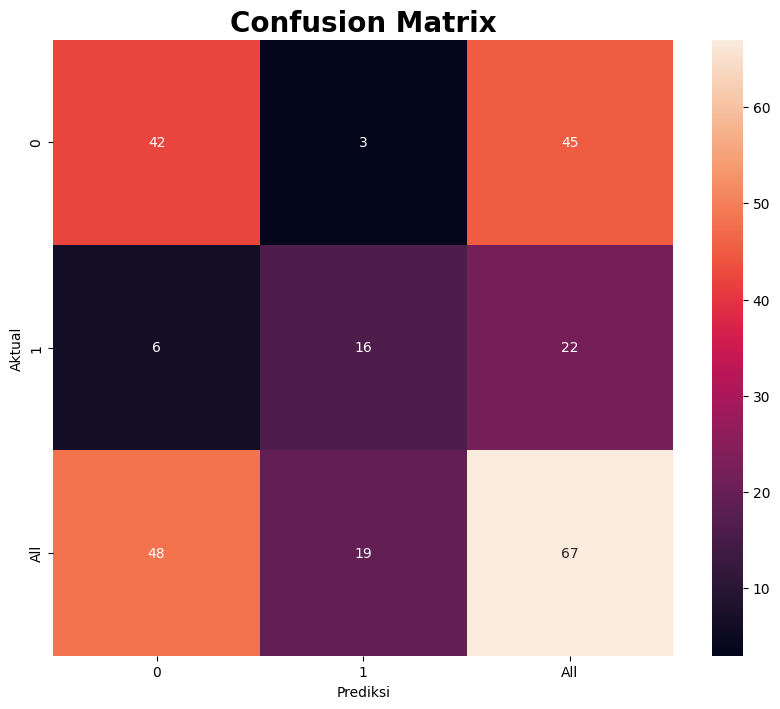

,0,1,All
0,42,3,45
1,6,16,22
All,48,19,67


In [ ]:
data_confusion = pd.crosstab(y_test, y_pred_test2, margins=True)
data_confusion.columns = data_confusion.columns.tolist()
data_confusion.index = data_confusion.index.tolist()
    
plt.figure(figsize=(10, 8))
plt.title('Confusion Matrix', size=20, weight='bold')
sns.heatmap(data_confusion, annot=True, fmt='d')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

display(data_confusion)

### 4. Reverse Encoding untuk Visualisasi

In [ ]:
def reverse_mapping(mapping):
    return {v: k for k, v in mapping.items()}

reverse_map_yes_no = reverse_mapping(map_yes_no)
dataset["Recurred"] = dataset["Recurred"].map(reverse_map_yes_no)

C:\Users\nizam\AppData\Local\Temp\ipykernel_19588\1248064517.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset["Recurred"] = dataset["Recurred"].map(reverse_map_yes_no)


In [ ]:
dataset

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred,Spread Level
0,27,1,0,0,0,0,0,0,0,0,0,2,No,0
1,34,1,0,0,0,0,0,0,0,0,0,0,No,0
2,30,1,0,0,0,0,0,0,0,0,0,0,No,0
3,62,1,0,0,0,0,0,0,0,0,0,0,No,0
4,62,1,0,0,0,1,0,0,0,0,0,0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,0,1,1,1,0,2,6,2,1,4,3,Yes,9
379,81,0,1,1,1,1,2,6,2,1,4,1,Yes,9
380,72,0,0,1,1,1,2,6,2,1,4,1,Yes,9
381,61,0,1,1,3,1,2,6,2,0,3,1,Yes,8


### 5. Analisa Korelasi Ftur dengan Fitur

#### *a. Fitur Numerik*

#### *b. Fitur Kategorikal*

## ***C. Evaluasi Model***

### 1. Confusion Matrix

#### *a. Fungsi Confusion Matrix*

In [ ]:
def confusion_matrix(y_true, y_pred, average):
    accuracy_array = []
    precision_array = []
    recall_array = []
    f1_array = []

    labels = np.unique(y_true)

    for label in labels:
        TP = np.sum((y_true == label) & (y_pred == label))
        FP = np.sum((y_true != label) & (y_pred == label))

        TN = np.sum((y_true != label) & (y_pred != label))
        FN = np.sum((y_true == label) & (y_pred != label))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)

        accuracy_array.append(accuracy)
        precision_array.append(precision)
        recall_array.append(recall)
        f1_array.append(f1_score)

    if average == 'macro':
        accuracy = np.mean(accuracy_array)
        precision = np.mean(precision_array)
        recall = np.mean(recall_array)
        f1_score = np.mean(f1_array)

    elif average == "micro":
        TP = np.sum(y_true == y_pred)
        FP = np.sum((y_true != y_pred) & (y_pred != y_true))

        TN = np.sum(y_true == y_pred)
        FN  = np.sum((y_true == y_pred) & (y_true != y_pred))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if  (TP + TN + FP + FN) != 0 else 0
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall)
    
    return accuracy, precision, recall, f1_score

#### *b. Evaluasi Training Model*

Manhattan Distance

In [ ]:
acccuracy_train1, precision_train1, recall_train1, f1_score_train1 = confusion_matrix(y_train, y_pred_train1, average='micro')
print('-' * 30)
print(f"Akurasi train: {acccuracy_train1:.2f}")
print('-' * 30)
print(f"Presisi train: {precision_train1:.2f}")
print('-' * 30)
print(f"Recall train: {recall_train1:.2f}")
print('-' * 30)
print(f"F1 Score train: {f1_score_train1:.2f}")
print('-' * 30)

------------------------------
Akurasi train: 0.95
------------------------------
Presisi train: 0.90
------------------------------
Recall train: 1.00
------------------------------
F1 Score train: 0.95
------------------------------


Euclidean Distance

In [ ]:
acccuracy_train2, precision_train2, recall_train2, f1_score_train2 = confusion_matrix(y_train, y_pred_train2, average='micro')
print('-' * 30)
print(f"Akurasi train: {acccuracy_train2:.2f}")
print('-' * 30)
print(f"Presisi train: {precision_train2:.2f}")
print('-' * 30)
print(f"Recall train: {recall_train2:.2f}")
print('-' * 30)
print(f"F1 Score train: {f1_score_train2:.2f}")
print('-' * 30)

------------------------------
Akurasi train: 0.93
------------------------------
Presisi train: 0.87
------------------------------
Recall train: 1.00
------------------------------
F1 Score train: 0.93
------------------------------


#### *c. Evaluasi Testing Model*

Manhattan Distance

In [ ]:
acccuracy_test1, precision_test1, recall_test1, f1_score_test1 = confusion_matrix(y_test, y_pred_test1, average='micro')
print('-' * 30)
print(f"Akurasi test: {acccuracy_test1:.2f}")
print('-' * 30)
print(f"Presisi test: {precision_test1:.2f}")
print('-' * 30)
print(f"Recall test: {recall_test1:.2f}")
print('-' * 30)
print(f"F1 Score test: {f1_score_test1:.2f}")
print('-' * 30)

------------------------------
Akurasi test: 0.94
------------------------------
Presisi test: 0.88
------------------------------
Recall test: 1.00
------------------------------
F1 Score test: 0.94
------------------------------


Euclidean Distance

In [ ]:
acccuracy_test2, precision_test2, recall_test2, f1_score_test2 = confusion_matrix(y_test, y_pred_test2, average='micro')
print('-' * 30)
print(f"Akurasi test: {acccuracy_test2:.2f}")
print('-' * 30)
print(f"Presisi test: {precision_test2:.2f}")
print('-' * 30)
print(f"Recall test: {recall_test2:.2f}")
print('-' * 30)
print(f"F1 Score test: {f1_score_test2:.2f}")
print('-' * 30)

------------------------------
Akurasi test: 0.93
------------------------------
Presisi test: 0.87
------------------------------
Recall test: 1.00
------------------------------
F1 Score test: 0.93
------------------------------


### 2. Bias dan Variance Model

In [ ]:
bias_knn1 = 1 - acccuracy_test1
variance_knn1 = acccuracy_train1 - acccuracy_test1
bias_knn2 = 1 - acccuracy_test2
variance_knn2 = acccuracy_train2 - acccuracy_test2

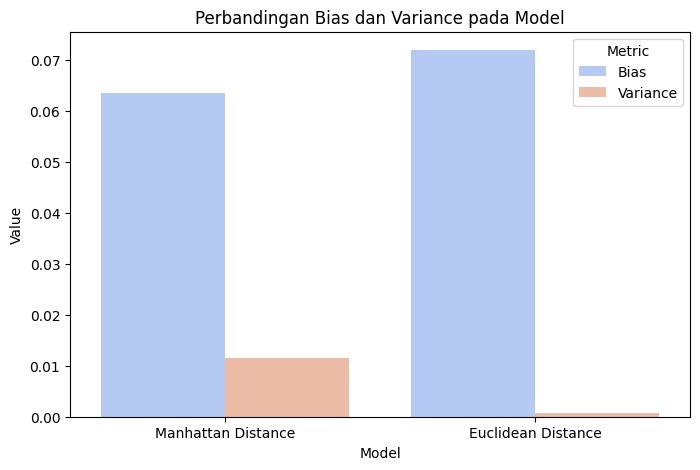

In [ ]:
data = {
    "Model": ["Manhattan Distance", "Manhattan Distance", "Euclidean Distance", "Euclidean Distance"],
    "Metric": ["Bias", "Variance", "Bias", "Variance"],
    "Value": [bias_knn1, variance_knn1, bias_knn2, variance_knn2]
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric", palette="coolwarm")

plt.xlabel("Model")
plt.ylabel("Value")
plt.title("Perbandingan Bias dan Variance pada Model")
plt.legend(title="Metric")

plt.show()

### 3. K-Fold Cross Validation

#### *a. Fungsi K-Fold*

In [ ]:
def stratified_k_fold(X, y, model, k = 7):

    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = confusion_matrix(y_test, y_pred, average='micro')
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy}")
    
    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc}")
    print(f"Total Standard Deviation: {std_dev}")

    return avg_acc, std_dev

#### *b. Model K-Fold*

Manhattan Distance

In [ ]:
k_fold = stratified_k_fold(X_test_famd, y_test, model1, k=7)

Fold: 1 | Accuracy: 0.91 | F1 Score: 0.86
Fold: 2 | Accuracy: 0.80 | F1 Score: 0.50
Fold: 3 | Accuracy: 0.90 | F1 Score: 0.86
Fold: 4 | Accuracy: 0.78 | F1 Score: 0.50
Fold: 5 | Accuracy: 0.89 | F1 Score: 0.80
Fold: 6 | Accuracy: 0.78 | F1 Score: 0.67
Fold: 7 | Accuracy: 0.89 | F1 Score: 0.80

Average Accuracy Between Folds: 0.85
Total Standard Deviation: 0.06


Euclidean Distance

In [ ]:
k_fold = stratified_k_fold(X_test_famd, y_test, model2, k=7)

Fold: 1 | Accuracy: 0.82 | F1 Score: 0.67
Fold: 2 | Accuracy: 0.70 | F1 Score: 0.57
Fold: 3 | Accuracy: 0.90 | F1 Score: 0.80
Fold: 4 | Accuracy: 0.89 | F1 Score: 0.80
Fold: 5 | Accuracy: 0.89 | F1 Score: 0.80
Fold: 6 | Accuracy: 1.00 | F1 Score: 1.00
Fold: 7 | Accuracy: 0.67 | F1 Score: 0.40

Average Accuracy Between Folds: 0.84
Total Standard Deviation: 0.11


# **IV. Final Evaluation**

Setelah berbagai proses analisis, feature engineering, dan modeling yang telah dilakukan, kita bisa menarik beberapa kesimpulan, antara lain:

1. Faktor `Age` seseorang sangat mempengaruhi kambuhnya kanker tiroid pada pasien, mengingat kondisi tubuh orang yang semakin berumur lebih rapuh sehingga ia semakin rentan terhadap penyakit.

2. Faktor lain yang dapat menentukan apabila kanker tiroid akan kambuh kembali pada pasien adalah bagaimana respon tubuh pasien setelah diberikan treatment (`Response`). Jika responnya semakin buruk, maka resiko kambuh semakin tinggi.

3. Seberapa tersebarnya kanker dalam tubuh juga menjadi salah satu faktor utama kambuhnya kanker pasien (`Spread Level`).

4. Model sudah bisa menghasilkan prediksi yang bagus dan konsisten. Akan lebih bagus lagi jika observasi tetap dilanjutkan untuk memperbanyak data sehingga model dapat menghasilkan prediksi yang lebih baik lagi.

Yang bisa kami katakan pada pihak rumah sakit dan dokter spesialis kanker di luar sana:

1. Dari data yang ada sejauh ini, memang ketiga faktor yang sudah disebutkan sebelumnya merupakan faktor utama kambuhnya kanker tiroid. Akan tetapi, semua faktor yang ada merupakan data penting dan bisa lebih menjelaskan penyebab kambuhnya kanker tiroid, tidak hanya faktor utamanya saja. Maka dari itu, akan lebih baik lagi jika dokter bisa melakukan tes di faktor lainnya yang diasumsikan berpotensi menjadi penyebab kambuhnya kanker.

2. Apabila dokter akan menggunakan model untuk menghasilkan asumsi awal, keputusan akhir tetap ada di tangan sang dokter. Hasil prediksi dari model tidak seharusnya dijadikan patokan karena ada banyak sekali faktor di lapangan, yang bahkan di luar dari dataset, yang perlu dokter ketahui, sehingga seakurat apapun hasil prediksi yang dibuat model, kemungkinan meleset dari kejadian di dunia nyata sangat tinggi, terutama ini merupakan kasus medis dan berhubungan dengan kanker, yang berarti ini kasus yang sangat serius. Dari hasil prediksi yang dijadikan sebagai asumsi awal, dokter bisa melakukan pemeriksaan lebih lanjut dan menentukan langkah selanjutnya untuk treatment yang perlu dilakukan.

---
Copyright @ 2025. SMK Negeri 8 Malang. All rights reseved.